# Appendix: Effect of Daily Robot Contact on Human Ratings

This notebook focuses on one exploratory appendix observation: participants who report daily robot contact tend to rate the robot videos more severely.

We do **not** treat this as a confirmatory statistical claim. The daily-contact subgroup is small, so the result should be written as a descriptive signal: interesting, directionally consistent after averaging policies, and worth reporting as a rater-calibration effect.

The notebook produces:

1. readable notebook figures for Policy A, Policy B, and the participant-level mean across both policies;
2. participant-bootstrap confidence intervals and effect sizes;
3. compact vertical figures suitable for an IEEE-style paper column;
4. paper-ready prose with cautious but positive wording.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

AXES = ["competence_control", "safety", "awareness", "positive_impression"]
AXIS_LABELS = {
    "competence_control": "Dexterity",
    "safety": "Safety",
    "awareness": "Social Awareness",
    "positive_impression": "Impression",
    "overall": "Overall",
}
POLICY_LABELS = {
    "A": "Policy A",
    "B": "Policy B",
    "All": "Participant mean across Policies A and B",
}
GROUP_LABELS = {
    False: "No daily robot contact",
    True: "Daily robot contact",
}
GROUP_COLORS = {
    "No daily robot contact": "#2F6B9A",
    "Daily robot contact": "#D66A35",
}

NO_CONTACT = "No daily robot contact"
DAILY_CONTACT = "Daily robot contact"
BOOTSTRAP_RESAMPLES = 10000
BOOTSTRAP_SEED = 20260601

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 350,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [2]:
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path("paper") / "notebooks"
PAPER_DIR = NOTEBOOK_DIR.parent
ANALYSIS_DIR = PAPER_DIR / "data" / "human-survey" / "analysis_outputs"
DATA_PATH = ANALYSIS_DIR / "survey_long.csv"
OUTPUT_DIR = ANALYSIS_DIR / "appendix_results" / "robot_experience"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def paper_path(path):
    return Path(path).relative_to(PAPER_DIR)


def save_figure(fig, stem):
    png_path = OUTPUT_DIR / f"{stem}.png"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"Saved {paper_path(png_path)}")
    print(f"Saved {paper_path(pdf_path)}")


print(f"Reading: {paper_path(DATA_PATH)}")
print(f"Writing: {paper_path(OUTPUT_DIR)}")

Reading: paper/data/human-survey/analysis_outputs/survey_long.csv
Writing: paper/data/human-survey/analysis_outputs/appendix_results/robot_experience


## Prepare the Data

The survey uses a `-3` to `+3` Likert scale. We convert it to `0` to `100` so the values match the rest of the paper figures.

For each participant, policy, and axis, we average the first-person and third-person videos. The combined policy panel is then computed as the participant-level mean across Policy A and Policy B.

In [3]:
survey = pd.read_csv(DATA_PATH)

answers = survey[survey["axis"].isin(AXES)].copy()
answers = answers.dropna(subset=["robotics_familiarity"])
answers["score_0_100"] = (answers["score"].astype(float) + 3.0) / 6.0 * 100.0
answers["experience_group"] = answers["robotics_familiarity"].map(GROUP_LABELS)

participant_policy_axis = (
    answers.groupby(["participant_id", "experience_group", "policy", "axis"], as_index=False)
    .agg(score_0_100=("score_0_100", "mean"))
)

participant_combined_axis = (
    participant_policy_axis.groupby(["participant_id", "experience_group", "axis"], as_index=False)
    .agg(score_0_100=("score_0_100", "mean"))
)
participant_combined_axis["policy"] = "All"

analysis_scores = pd.concat([participant_policy_axis, participant_combined_axis], ignore_index=True)
analysis_scores["policy_label"] = analysis_scores["policy"].map(POLICY_LABELS)
analysis_scores["axis_label"] = analysis_scores["axis"].map(AXIS_LABELS)

group_sizes = (
    answers[["participant_id", "experience_group"]]
    .drop_duplicates()
    .groupby("experience_group")
    .size()
    .rename("n_participants")
    .reset_index()
)

display(group_sizes)
analysis_scores.head()

,experience_group,n_participants
0,Daily robot contact,13
1,No daily robot contact,56


,participant_id,experience_group,policy,axis,score_0_100,policy_label,axis_label
0,1,Daily robot contact,A,awareness,16.666667,Policy A,Social Awareness
1,1,Daily robot contact,A,competence_control,66.666667,Policy A,Dexterity
2,1,Daily robot contact,A,positive_impression,58.333333,Policy A,Impression
3,1,Daily robot contact,A,safety,83.333333,Policy A,Safety
4,1,Daily robot contact,B,awareness,0.000000,Policy B,Social Awareness


## Descriptive Mean Scores

Negative values in `daily_minus_no_contact` mean the daily robot-contact group gave lower scores.

In [4]:
mean_scores = (
    analysis_scores.groupby(["policy", "policy_label", "axis", "axis_label", "experience_group"], as_index=False)
    .agg(mean_score=("score_0_100", "mean"), n_participants=("participant_id", "nunique"))
)

score_table = (
    mean_scores.pivot_table(
        index=["policy", "policy_label", "axis", "axis_label"],
        columns="experience_group",
        values="mean_score",
    )
    .reset_index()
)
score_table["daily_minus_no_contact"] = score_table[DAILY_CONTACT] - score_table[NO_CONTACT]
score_table["axis_order"] = score_table["axis"].map({axis: index for index, axis in enumerate(AXES)})
score_table["policy_order"] = score_table["policy"].map({"A": 0, "B": 1, "All": 2})
score_table = score_table.sort_values(["policy_order", "axis_order"]).drop(columns=["policy_order", "axis_order"])

score_table_path = OUTPUT_DIR / "robot_experience_mean_scores.csv"
score_table.to_csv(score_table_path, index=False)

display(score_table.round(1))
print(f"Saved {paper_path(score_table_path)}")

experience_group,policy,policy_label,axis,axis_label,Daily robot contact,No daily robot contact,daily_minus_no_contact
1,A,Policy A,competence_control,Dexterity,55.1,53.9,1.3
3,A,Policy A,safety,Safety,37.2,39.9,-2.7
0,A,Policy A,awareness,Social Awareness,28.2,38.2,-10.0
2,A,Policy A,positive_impression,Impression,44.2,50.7,-6.5
9,B,Policy B,competence_control,Dexterity,23.7,35.6,-11.8
11,B,Policy B,safety,Safety,29.5,35.7,-6.2
8,B,Policy B,awareness,Social Awareness,30.1,34.4,-4.2
10,B,Policy B,positive_impression,Impression,29.5,39.7,-10.2
5,All,Participant mean across Policies A and B,competence_control,Dexterity,39.4,44.7,-5.3
7,All,Participant mean across Policies A and B,safety,Safety,33.3,37.8,-4.5


Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_mean_scores.csv


## Participant-Bootstrap Evidence

The subgroup comparison is exploratory. To avoid pretending the many axes are independent observations, the bootstrap below resamples participants within each experience group.

The aggregate policy effects average the four axes within each participant. The axis effects use the participant-level mean across Policy A and Policy B for each axis.

In [5]:
def hedges_g(daily_values, no_contact_values):
    daily_values = np.asarray(daily_values, dtype=float)
    no_contact_values = np.asarray(no_contact_values, dtype=float)
    n_daily = len(daily_values)
    n_no_contact = len(no_contact_values)
    pooled_variance = (
        (n_daily - 1) * daily_values.var(ddof=1)
        + (n_no_contact - 1) * no_contact_values.var(ddof=1)
    ) / (n_daily + n_no_contact - 2)
    pooled_sd = np.sqrt(pooled_variance)
    if pooled_sd == 0:
        return np.nan
    correction = 1 - 3 / (4 * (n_daily + n_no_contact) - 9)
    return correction * ((daily_values.mean() - no_contact_values.mean()) / pooled_sd)


def bootstrap_difference(daily_values, no_contact_values, seed):
    daily_values = np.asarray(daily_values, dtype=float)
    no_contact_values = np.asarray(no_contact_values, dtype=float)
    rng = np.random.default_rng(seed)

    daily_indices = rng.integers(0, len(daily_values), size=(BOOTSTRAP_RESAMPLES, len(daily_values)))
    no_contact_indices = rng.integers(0, len(no_contact_values), size=(BOOTSTRAP_RESAMPLES, len(no_contact_values)))
    bootstrap_diffs = daily_values[daily_indices].mean(axis=1) - no_contact_values[no_contact_indices].mean(axis=1)

    mean_diff = daily_values.mean() - no_contact_values.mean()
    ci_low, ci_high = np.quantile(bootstrap_diffs, [0.025, 0.975])
    return {
        "daily_minus_no_contact": float(mean_diff),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "daily_minus_no_contact_likert": float(mean_diff * 6 / 100),
        "hedges_g": float(hedges_g(daily_values, no_contact_values)),
        "n_daily_contact": int(len(daily_values)),
        "n_no_daily_contact": int(len(no_contact_values)),
    }


def compare_groups(frame, value_column="score_0_100", seed=BOOTSTRAP_SEED):
    daily_values = frame.loc[frame["experience_group"] == DAILY_CONTACT, value_column].to_numpy(dtype=float)
    no_contact_values = frame.loc[frame["experience_group"] == NO_CONTACT, value_column].to_numpy(dtype=float)
    return bootstrap_difference(daily_values, no_contact_values, seed)

In [6]:
policy_effect_rows = []
for seed_offset, policy in enumerate(["A", "B", "All"]):
    participant_policy_mean = (
        analysis_scores[analysis_scores["policy"] == policy]
        .groupby(["participant_id", "experience_group"], as_index=False)
        .agg(score_0_100=("score_0_100", "mean"))
    )
    result = compare_groups(participant_policy_mean, seed=BOOTSTRAP_SEED + seed_offset)
    result.update({"policy": policy, "policy_label": POLICY_LABELS[policy]})
    policy_effect_rows.append(result)

policy_effects = pd.DataFrame(policy_effect_rows)
policy_effects_path = OUTPUT_DIR / "robot_experience_policy_effects_bootstrap.csv"
policy_effects.to_csv(policy_effects_path, index=False)

display(policy_effects.round(3))
print(f"Saved {paper_path(policy_effects_path)}")

,daily_minus_no_contact,ci_low,ci_high,daily_minus_no_contact_likert,hedges_g,n_daily_contact,n_no_daily_contact,policy,policy_label
0,-4.499,-16.229,7.349,-0.270,-0.208,13,56,A,Policy A
1,-8.142,-19.821,4.665,-0.488,-0.393,13,56,B,Policy B
2,-6.320,-16.197,4.837,-0.379,-0.332,13,56,All,Participant mean across Policies A and B


Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_policy_effects_bootstrap.csv


In [7]:
axis_effect_rows = []
combined_scores = analysis_scores[analysis_scores["policy"] == "All"].copy()

for seed_offset, axis in enumerate(AXES):
    axis_frame = combined_scores[combined_scores["axis"] == axis]
    result = compare_groups(axis_frame, seed=BOOTSTRAP_SEED + 100 + seed_offset)
    result.update({"axis": axis, "axis_label": AXIS_LABELS[axis]})
    axis_effect_rows.append(result)

overall_frame = (
    combined_scores.groupby(["participant_id", "experience_group"], as_index=False)
    .agg(score_0_100=("score_0_100", "mean"))
)
overall_result = compare_groups(overall_frame, seed=BOOTSTRAP_SEED + 200)
overall_result.update({"axis": "overall", "axis_label": "Overall"})
axis_effect_rows.insert(0, overall_result)

axis_effects = pd.DataFrame(axis_effect_rows)
axis_effects_path = OUTPUT_DIR / "robot_experience_axis_effects_bootstrap.csv"
axis_effects.to_csv(axis_effects_path, index=False)

display(axis_effects.round(3))
print(f"Saved {paper_path(axis_effects_path)}")

,daily_minus_no_contact,ci_low,ci_high,daily_minus_no_contact_likert,hedges_g,n_daily_contact,n_no_daily_contact,axis,axis_label
0,-6.320,-16.289,4.751,-0.379,-0.332,13,56,overall,Overall
1,-5.294,-15.706,5.232,-0.318,-0.259,13,56,competence_control,Dexterity
2,-4.464,-16.129,8.196,-0.268,-0.206,13,56,safety,Safety
3,-7.143,-18.768,5.775,-0.429,-0.333,13,56,awareness,Social Awareness
4,-8.379,-18.796,3.073,-0.503,-0.421,13,56,positive_impression,Impression


Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_axis_effects_bootstrap.csv


## Notebook Figures

These wide figures are useful for inspecting the pattern inside the notebook. The radar plot uses a truncated radial axis (`15-60`) for readability, so the shift plot is the more honest effect-size view.

Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_profiles_by_policy.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_profiles_by_policy.pdf


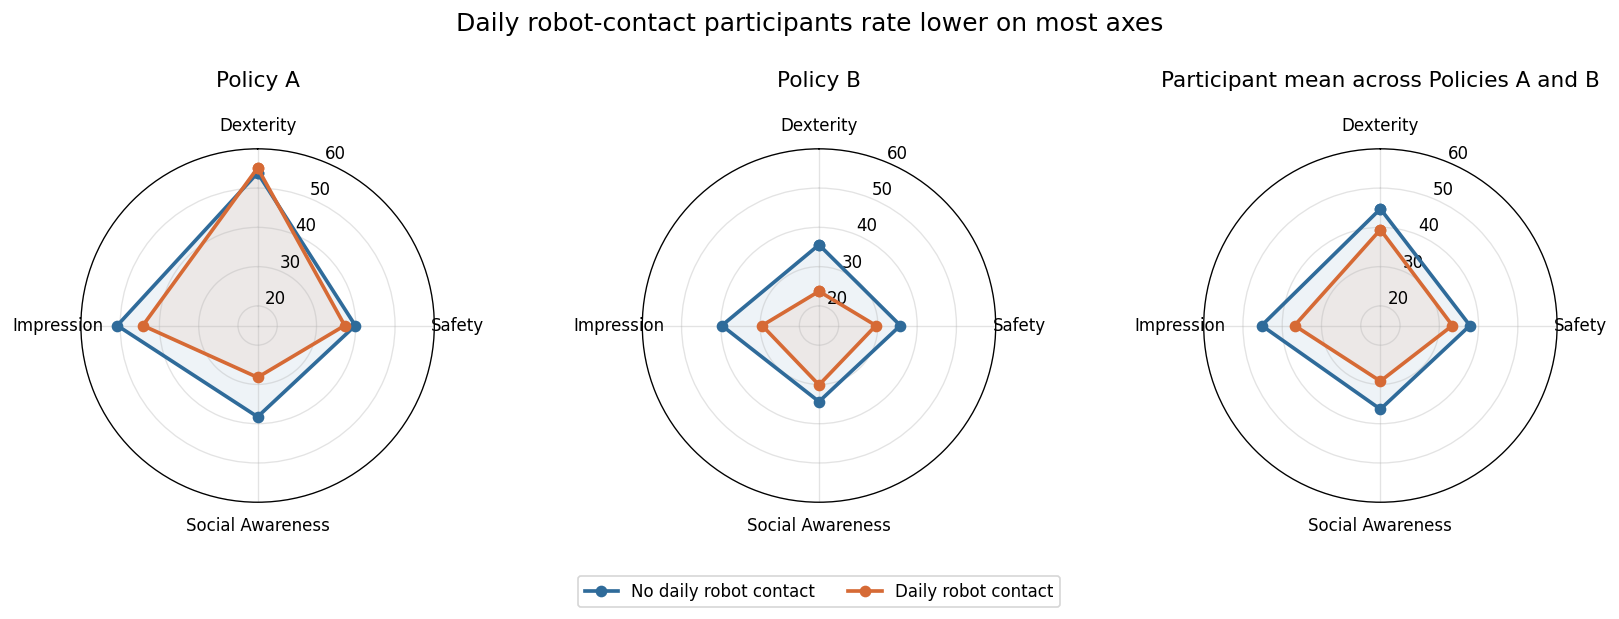

In [8]:
def close_loop(values):
    values = list(values)
    return values + values[:1]


def values_for(policy, group):
    rows = score_table[score_table["policy"] == policy].set_index("axis").loc[AXES]
    return rows[group].to_numpy(dtype=float)


angles = np.linspace(0, 2 * np.pi, len(AXES), endpoint=False)
closed_angles = close_loop(angles)

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.8), subplot_kw={"projection": "polar"})
for ax, policy in zip(axes, ["A", "B", "All"]):
    for group, color in GROUP_COLORS.items():
        values = values_for(policy, group)
        ax.plot(closed_angles, close_loop(values), color=color, linewidth=2.2, marker="o", label=group)
        ax.fill(closed_angles, close_loop(values), color=color, alpha=0.08)

    ax.set_title(POLICY_LABELS[policy], pad=18)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([AXIS_LABELS[axis] for axis in AXES])
    ax.set_ylim(15, 60)
    ax.set_yticks([20, 30, 40, 50, 60])
    ax.set_yticklabels(["20", "30", "40", "50", "60"])
    ax.grid(alpha=0.35)

axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=True)
fig.suptitle("Daily robot-contact participants rate lower on most axes", y=1.04, fontsize=15)
fig.tight_layout()
save_figure(fig, "robot_experience_profiles_by_policy")
plt.show()

Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_shift_by_policy.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_shift_by_policy.pdf


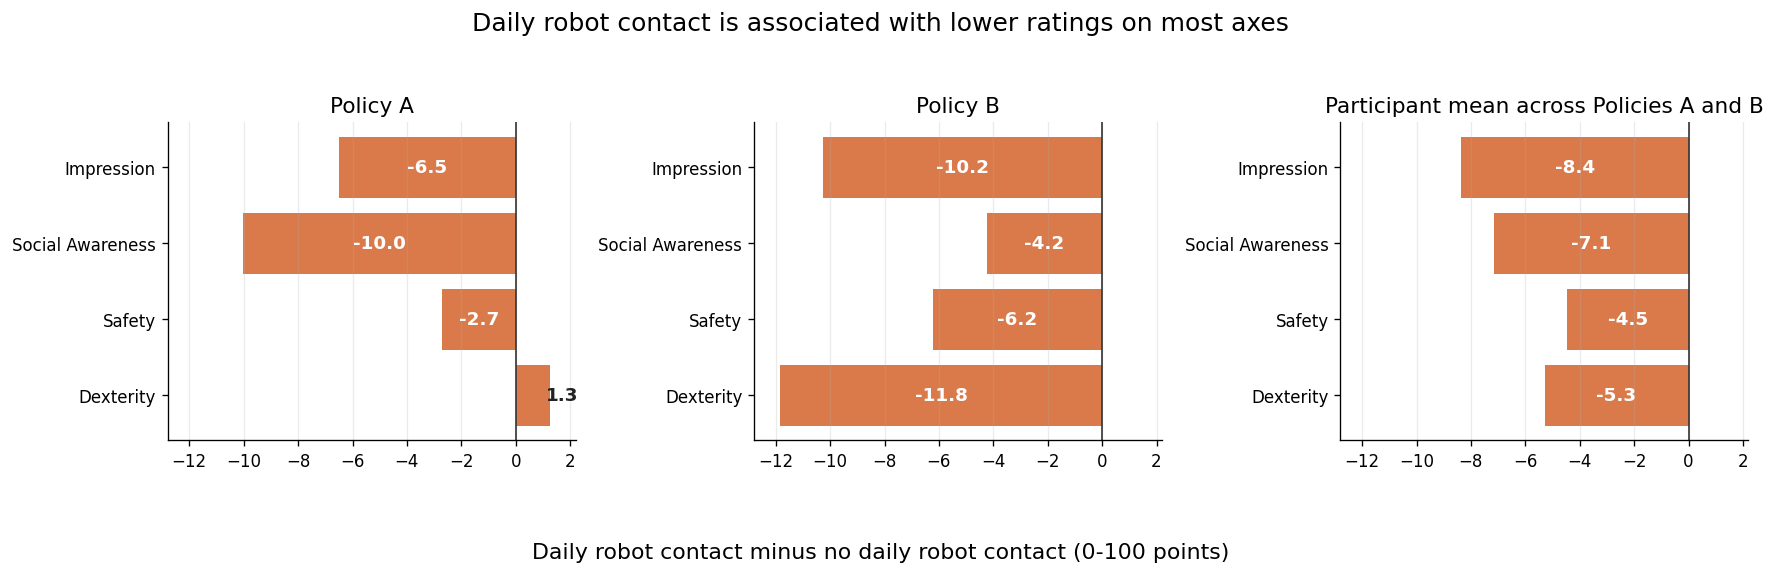

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.5), sharex=True)

for ax, policy in zip(axes, ["A", "B", "All"]):
    rows = score_table[score_table["policy"] == policy].set_index("axis").loc[AXES].reset_index()
    y = np.arange(len(rows))
    values = rows["daily_minus_no_contact"]

    bars = ax.barh(y, values, color="#D66A35", alpha=0.9)
    ax.axvline(0, color="#333333", linewidth=1.0)
    ax.set_title(POLICY_LABELS[policy])
    ax.set_yticks(y)
    ax.set_yticklabels(rows["axis_label"])
    ax.set_xlim(-12.8, 2.2)
    ax.grid(axis="x", alpha=0.25)

    for bar, value in zip(bars, values):
        text_x = value / 2 if value < 0 else value + 0.45
        text_color = "white" if value < -1 else "#222222"
        ax.text(text_x, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", ha="center", va="center", color=text_color, fontweight="bold")

fig.supxlabel("Daily robot contact minus no daily robot contact (0-100 points)", y=0.02)
fig.suptitle("Daily robot contact is associated with lower ratings on most axes", y=1.04, fontsize=15)
fig.tight_layout(rect=[0, 0.08, 1, 1])
save_figure(fig, "robot_experience_shift_by_policy")
plt.show()

## Paper-Ready Vertical Figures

For the paper, the most defensible figure is the compact CI plot below. It shows the exploratory pattern while making the uncertainty visible. The wide radar plot is better kept in the notebook.

Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_paper_policy_shift_vertical.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_paper_policy_shift_vertical.pdf


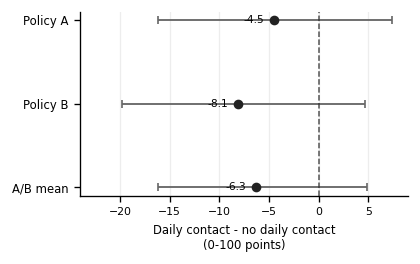

In [10]:
def plot_ci_points(ax, frame, label_column):
    plot_frame = frame.copy().iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_frame))
    mean = plot_frame["daily_minus_no_contact"]
    xerr = np.vstack([mean - plot_frame["ci_low"], plot_frame["ci_high"] - mean])

    ax.errorbar(
        mean,
        y,
        xerr=xerr,
        fmt="o",
        color="#222222",
        ecolor="#666666",
        elinewidth=1.1,
        capsize=2.5,
        markersize=4.8,
    )
    ax.axvline(0, color="#333333", linewidth=0.9, linestyle="--", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_frame[label_column])
    ax.set_xlabel("Daily contact - no daily contact\n(0-100 points)")
    ax.grid(axis="x", alpha=0.22)
    ax.set_xlim(-24, 9)

    for value, yi in zip(mean, y):
        text_x = value - 1.0 if value < 0 else value + 1.0
        horizontal_alignment = "right" if value < 0 else "left"
        ax.text(text_x, yi, f"{value:.1f}", ha=horizontal_alignment, va="center", fontsize=6.4)


policy_effects_for_plot = policy_effects.copy()
policy_effects_for_plot["paper_label"] = policy_effects_for_plot["policy"].map(
    {"A": "Policy A", "B": "Policy B", "All": "A/B mean"}
)

axis_effects_for_plot = axis_effects.copy()
axis_effects_for_plot["paper_label"] = axis_effects_for_plot["axis"].map(
    {
        "overall": "Overall",
        "competence_control": "Dexterity",
        "safety": "Safety",
        "awareness": "Social\nAware.",
        "positive_impression": "Impression",
    }
)

with plt.rc_context(
    {
        "font.size": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6.5,
        "ytick.labelsize": 7,
    }
):
    fig, ax = plt.subplots(figsize=(3.35, 2.05))
    plot_ci_points(ax, policy_effects_for_plot, "paper_label")
    fig.tight_layout(pad=0.25)
    save_figure(fig, "robot_experience_paper_policy_shift_vertical")
    plt.show()

Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_paper_axis_shift_vertical.png
Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_paper_axis_shift_vertical.pdf


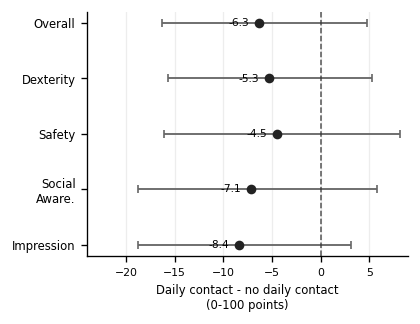

In [11]:
with plt.rc_context(
    {
        "font.size": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6.5,
        "ytick.labelsize": 7,
    }
):
    fig, ax = plt.subplots(figsize=(3.35, 2.55))
    plot_ci_points(ax, axis_effects_for_plot, "paper_label")
    fig.tight_layout(pad=0.25)
    save_figure(fig, "robot_experience_paper_axis_shift_vertical")
    plt.show()

## What I Would Put in the Paper

Use the paragraph below if you want a proud but careful appendix result. It reports the pattern as meaningful descriptive evidence, while clearly marking the subgroup analysis as exploratory.

In [12]:
combined = policy_effects.loc[policy_effects["policy"] == "All"].iloc[0]
policy_a = policy_effects.loc[policy_effects["policy"] == "A"].iloc[0]
policy_b = policy_effects.loc[policy_effects["policy"] == "B"].iloc[0]
negative_axis_count = int((axis_effects[axis_effects["axis"] != "overall"]["daily_minus_no_contact"] < 0).sum())
axis_count = len(AXES)
most_negative_axis = axis_effects[axis_effects["axis"] != "overall"].sort_values("daily_minus_no_contact").iloc[0]

def ci_text(row):
    return f"{row['daily_minus_no_contact']:.1f} [{row['ci_low']:.1f}, {row['ci_high']:.1f}]"

paper_text = f"""
### Rater Familiarity as a Calibration Signal

We also examined whether participants who reported daily robot contact used the rating scale differently from participants without daily robot contact. This subgroup analysis is exploratory because the groups are imbalanced (`n={int(combined['n_daily_contact'])}` daily-contact, `n={int(combined['n_no_daily_contact'])}` no daily-contact), but it reveals a consistent descriptive signal. After averaging each participant's ratings across both policies and all four perceptual axes, daily-contact participants rated the robots {abs(combined['daily_minus_no_contact']):.1f}/100 points lower on average (`95%` participant-bootstrap CI `{combined['ci_low']:.1f}` to `{combined['ci_high']:.1f}`), corresponding to {abs(combined['daily_minus_no_contact_likert']):.2f} points on the original `-3` to `+3` Likert scale.

The direction of the effect was negative on {negative_axis_count}/{axis_count} axes after averaging policies, with the largest drop on {most_negative_axis['axis_label']} ({most_negative_axis['daily_minus_no_contact']:.1f}/100). The policy-level means show the same downward tendency overall: Policy A `{ci_text(policy_a)}` and Policy B `{ci_text(policy_b)}` points. We therefore interpret robot familiarity as a possible rater-calibration factor: more experienced observers may be more demanding, especially when judging qualitative motion and social behavior. Because the confidence intervals are wide and the subgroup is small, we do not treat this as a confirmatory effect; rather, it motivates reporting rater familiarity and stratifying future human-validation studies by prior robot exposure.
""".strip()

paper_text_path = OUTPUT_DIR / "robot_experience_paper_text.md"
paper_text_path.write_text(paper_text + "\n")

display(Markdown(paper_text))
print(f"Saved {paper_path(paper_text_path)}")

### Rater Familiarity as a Calibration Signal

We also examined whether participants who reported daily robot contact used the rating scale differently from participants without daily robot contact. This subgroup analysis is exploratory because the groups are imbalanced (`n=13` daily-contact, `n=56` no daily-contact), but it reveals a consistent descriptive signal. After averaging each participant's ratings across both policies and all four perceptual axes, daily-contact participants rated the robots 6.3/100 points lower on average (`95%` participant-bootstrap CI `-16.2` to `4.8`), corresponding to 0.38 points on the original `-3` to `+3` Likert scale.

The direction of the effect was negative on 4/4 axes after averaging policies, with the largest drop on Impression (-8.4/100). The policy-level means show the same downward tendency overall: Policy A `-4.5 [-16.2, 7.3]` and Policy B `-8.1 [-19.8, 4.7]` points. We therefore interpret robot familiarity as a possible rater-calibration factor: more experienced observers may be more demanding, especially when judging qualitative motion and social behavior. Because the confidence intervals are wide and the subgroup is small, we do not treat this as a confirmatory effect; rather, it motivates reporting rater familiarity and stratifying future human-validation studies by prior robot exposure.

Saved paper/data/human-survey/analysis_outputs/appendix_results/robot_experience/robot_experience_paper_text.md


In [13]:
outputs = sorted(path for path in OUTPUT_DIR.iterdir() if path.is_file())
display(pd.DataFrame({"output_file": [str(paper_path(path)) for path in outputs]}))

,output_file
0,paper/data/human-survey/analysis_outputs/appen...
1,paper/data/human-survey/analysis_outputs/appen...
2,paper/data/human-survey/analysis_outputs/appen...
3,paper/data/human-survey/analysis_outputs/appen...
4,paper/data/human-survey/analysis_outputs/appen...
5,paper/data/human-survey/analysis_outputs/appen...
6,paper/data/human-survey/analysis_outputs/appen...
7,paper/data/human-survey/analysis_outputs/appen...
8,paper/data/human-survey/analysis_outputs/appen...
9,paper/data/human-survey/analysis_outputs/appen...
